<a href="https://colab.research.google.com/github/astiakamila/Processing-Text/blob/main/102_(Velyn)_162_(Astia)_Text_Pre_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Tugas Pemteks Text Pre-processing </h1>
<h2> Astia Kamila Dwi Septiani </h2>
<h3> NIM: 25031554162 </h3>
<h2> Zikrah Neisya Fabiola Evelyna </h2>
<h3> Nim: 25031554102 </h3>

Install dan Import Library

In [ ]:
pip install requests beautifulsoup4 pandas demoji nltk PySastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 10.8 MB/s eta 0:00:00


In [ ]:
import re
import string
import warnings
from io import StringIO

import demoji
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import requests
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud

Merapikan Tampilan Output Notebook dengan Mengabaikan Warning

In [ ]:
warnings.filterwarnings('ignore')

Mengunduh Stopwords NLTK

In [ ]:
nltk.download('stopwords', quiet=True)

True

Inisialisasi Stemmer Sastrawi

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

1. Fungsi preprocessing text

In [ ]:
def remove_html(text):
    return re.sub(r'<.*?>', '', str(text))

def remove_hashtag(text):
    return re.sub(r'#\w+', '', str(text))

def case_folding(text):
    return str(text).lower()

def remove_urls_and_emails(text):
    text = re.sub(r'https?://\S+', '', str(text))
    text = re.sub(r'http\S+', '', str(text))
    text = re.sub(r'www\S+', '', str(text))
    text = re.sub(r'\S+@\S+', '', str(text))
    return text

def remove_punctuation(text):
    text = re.sub(r'(:\)|:-\)|:D|:-D|;\)|;-\))', '', str(text))
    text = str(text).translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_emoji(text):
    return demoji.replace(str(text), repl="")

def remove_stopwords_id(text):
    sw = set(stopwords.words('indonesian'))
    return " ".join([word for word in str(text).split() if word not in sw])

def remove_stopwords_en(text):
    sw = set(stopwords.words('english'))
    return " ".join([word for word in str(text).split() if word not in sw])

def stem_text(text):
    return stemmer.stem(str(text))

2. SCRAPING DAN PREPROCESSING DATA CUACA (BMKG)

In [ ]:
print("1. Scraping Data Cuaca BMKG...")
url_cuaca = "https://www.bmkg.go.id/cuaca/prakiraan-cuaca-indonesia.bmkg"
headers = {"User-Agent": "Mozilla/5.0"}

data_cuaca = []
try:
    res = requests.get(url_cuaca, headers=headers, timeout=10)
    if res.status_code == 200:
        soup = BeautifulSoup(res.text, "html.parser")
        elements = soup.find_all(['p', 'td', 'div'], class_=re.compile(r'cuaca|weather|deskripsi', re.I))
        for el in elements:
            txt = el.get_text(strip=True)
            if len(txt) > 10:
                data_cuaca.append(txt)
except Exception as e:
    print(f"Catatan scraping BMKG: {e}")

if not data_cuaca:
    data_cuaca = [
        "Prakiraan cuaca wilayah Surabaya cerah berawan pada pagi hari dan berpotensi hujan ringan di sore hari.",
        "BMKG mengeluarkan peringatan dini cuaca ekstrem hujan lebat disertai angin kencang di sebagian wilayah Jawa Timur.",
        "Kondisi cuaca Jakarta diprakirakan cerah hingga berawan sepanjang hari ini.",
        "Suhu udara berkisar antara 24 hingga 33 derajat celsius dengan kelembapan tinggi.",
        "Hujan petir diprediksi terjadi di wilayah pegunungan pada malam hari nanti."
    ]

df_cuaca = pd.DataFrame({'teks_asli': data_cuaca})

df_cuaca['case_folding'] = df_cuaca['teks_asli'].apply(case_folding)
df_cuaca['rm_url'] = df_cuaca['case_folding'].apply(remove_urls_and_emails)
df_cuaca['rm_punc'] = df_cuaca['rm_url'].apply(remove_punctuation)
df_cuaca['rm_stopword'] = df_cuaca['rm_punc'].apply(remove_stopwords_id)
df_cuaca['stem'] = df_cuaca['rm_stopword'].apply(stem_text)

print("\nHasil Preprocessing Data Cuaca:")
print(df_cuaca[['rm_punc', 'stem']].head())


1. Scraping Data Cuaca BMKG...

Hasil Preprocessing Data Cuaca:
                                             rm_punc  \
0  prakiraan cuaca wilayah surabaya cerah berawan...   
1  bmkg mengeluarkan peringatan dini cuaca ekstre...   
2  kondisi cuaca jakarta diprakirakan cerah hingg...   
3  suhu udara berkisar antara 24 hingga 33 deraja...   
4  hujan petir diprediksi terjadi di wilayah pegu...   

                                                stem  
0  prakira cuaca wilayah surabaya cerah awan pagi...  
1  bmkg keluar ingat cuaca ekstrem hujan lebat se...  
2           kondisi cuaca jakarta prakira cerah awan  
3      suhu udara kisar 24 33 derajat celsius lembap  
4          hujan petir prediksi wilayah gunung malam  


3. SCRAPING DAN PREPROCESSING DATA FILM (WIKIPEDIA)

In [ ]:
print("\n2. Scraping Data Film Wikipedia...")
url_film = "https://en.wikipedia.org/wiki/List_of_highest-grossing_films"
res_film = requests.get(url_film, headers=headers)

if res_film.status_code == 200:
    soup = BeautifulSoup(res_film.text, "html.parser")
    table = soup.find("table", class_="wikitable")
    df_film = pd.read_html(StringIO(str(table)))[0]

    df_film = df_film[['Title']].copy()
    df_film.rename(columns={'Title': 'title_raw'}, inplace=True)

    df_film['title_clean'] = df_film['title_raw'].astype(str).str.replace('†', '', regex=False)
    df_film['case_folding'] = df_film['title_clean'].apply(case_folding)
    df_film['rm_punc'] = df_film['case_folding'].apply(remove_punctuation)
    df_film['rm_stopword'] = df_film['rm_punc'].apply(remove_stopwords_en)

    print("\nHasil Preprocessing Data Film:")
    print(df_film[['title_raw', 'rm_stopword']].head())


2. Scraping Data Film Wikipedia...

Hasil Preprocessing Data Film:
                     title_raw              rm_stopword
0                       Avatar                   avatar
1          Avengers: Endgame †         avengers endgame
2  Spider-Man: Brand New Day †  spiderman brand new day
3     Avatar: The Way of Water         avatar way water
4                      Titanic                  titanic


4. VISUALISASI WORDCLOUD CUACA


3. Menampilkan Visualisasi WordCloud Cuaca...


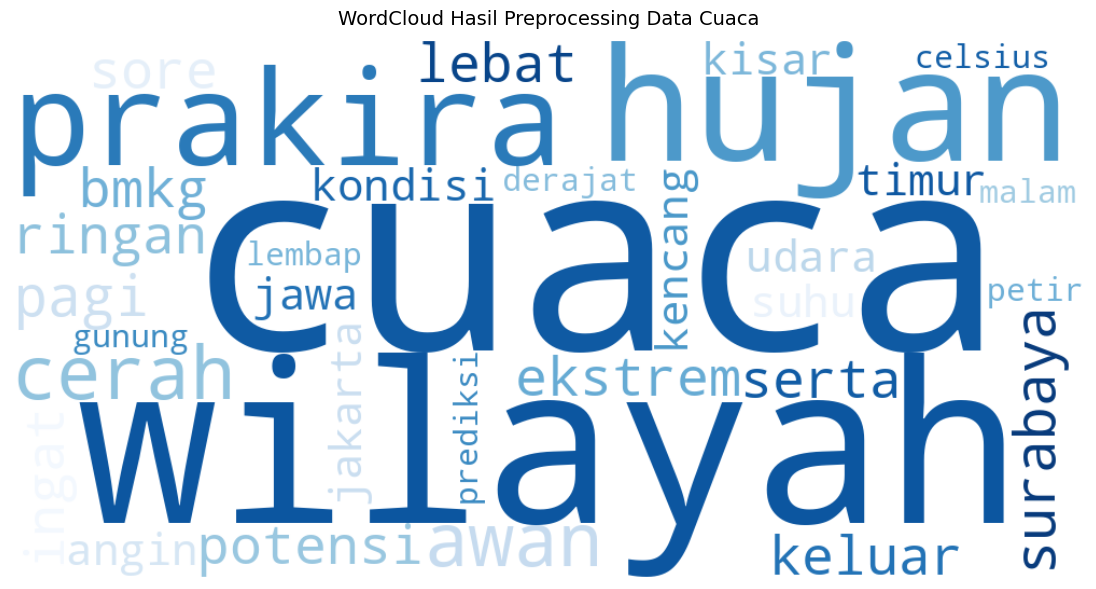

In [ ]:
print("\n3. Menampilkan Visualisasi WordCloud Cuaca...")
text_cuaca = " ".join(df_cuaca['stem'].dropna().tolist())

wordcloud_cuaca = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='Blues',
    max_words=200
).generate(text_cuaca)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_cuaca, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Hasil Preprocessing Data Cuaca', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

5. VISUALISASI WORDCLOUD FILM


4. Menampilkan Visualisasi WordCloud Film...


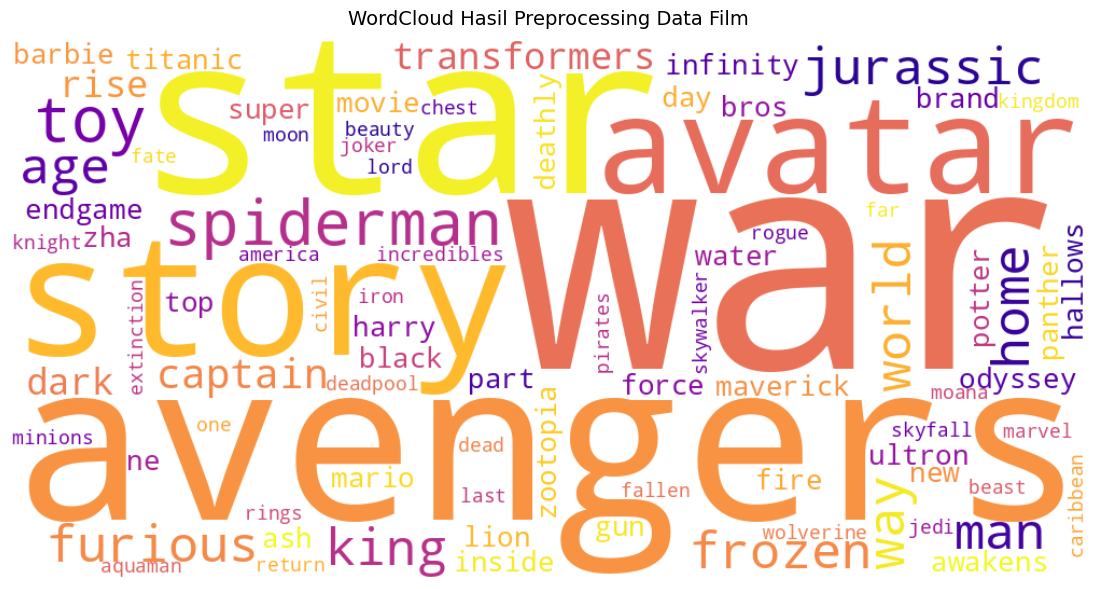

In [ ]:
print("\n4. Menampilkan Visualisasi WordCloud Film...")
text_film = " ".join(df_film['rm_stopword'].dropna().tolist())

wordcloud_film = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='plasma',
    max_words=200
).generate(text_film)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_film, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Hasil Preprocessing Data Film', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

6. SIMPAN HASIL KE FILE CSV

In [ ]:
df_cuaca.to_csv('hasil_preprocessing_cuaca.csv', index=False)
df_film.to_csv('hasil_preprocessing_film.csv', index=False)

print("\nHasil berhasil disimpan ke 'hasil_preprocessing_cuaca.csv' dan 'hasil_preprocessing_film.csv'.")


Hasil berhasil disimpan ke 'hasil_preprocessing_cuaca.csv' dan 'hasil_preprocessing_film.csv'.
